
# Proof of concept: context-dependent sequential memory

This notebook tests a minimal branching-memory mechanism in a Kuramoto-type oscillator network with \(N=40\) oscillators.

The two desired rules are

\[
(A,B)\to C,
\qquad
(D,B)\to E.
\]

Both trials are driven into the same present state \(B\), but retain different slow traces of the preceding state. After the external cue is removed, the history-dependent transition term should send the system toward \(C\) after \(A\to B\), and toward \(E\) after \(D\to B\).

This is a proof-of-concept model rather than a final formulation. In particular, it uses:

- binary phase patterns, \(\xi_i^\mu\in\{0,\pi\}\);
- a Hebbian phase-coupling matrix for static memory stabilization;
- a slow low-pass trace of past overlaps;
- externally imposed \(A\to B\) or \(D\to B\) cue periods;
- a context gate combining the slow previous-state trace with the current overlap with \(B\).

The notebook includes single-trial visualizations and a small robustness sweep over random seeds.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)



## 1. Model

For memory \(\mu\), define the complex overlap

\[
m_\mu(t)
=
\frac{1}{N}
\sum_{i=1}^{N}
e^{\mathrm{i}(\theta_i(t)-\xi_i^\mu)},
\qquad
q_\mu(t)=|m_\mu(t)|^2.
\]

The oscillator dynamics are

\[
\dot{\theta}_i
=
\omega_i
+
K_{\mathrm{mem}}
\sum_j J_{ij}\sin(\theta_j-\theta_i)
+
K_{\mathrm{tr}}F_i^{\mathrm{tr}}
+
K_{\mathrm{cue}}F_i^{\mathrm{cue}}.
\]

The slow trace satisfies

\[
\tau_s \dot{s}_\mu=q_\mu-s_\mu.
\]

The two context gates are

\[
g_C=s_Aq_B,
\qquad
g_E=s_Dq_B,
\]

and the transition force is

\[
F_i^{\mathrm{tr}}
=
g_C\sin(\xi_i^C-\theta_i)
+
g_E\sin(\xi_i^E-\theta_i).
\]

Thus, overlap with \(B\) activates a transition only when a suitable previous-state trace is still present.


In [2]:

MEMORY_NAMES = ["A", "B", "C", "D", "E"]
A, B, C, D, E = range(5)

DEFAULTS = dict(
    N=40,
    dt=0.02,
    T=55.0,
    K_mem=1.6,
    K_tr=8.0,
    K_cue=8.0,
    tau_s=10.0,
    frequency_std=0.03,
    phase_noise=0.01,
    cue_1_end=10.0,
    cue_B_end=22.0,
)


In [3]:

def make_memories(N=40, seed=3):
    """Generate five random binary phase memories and the Hebbian coupling matrix."""
    rng = np.random.default_rng(seed)
    patterns = rng.choice([0.0, np.pi], size=(5, N))

    J = np.zeros((N, N))
    for mu in range(5):
        J += np.cos(patterns[mu][:, None] - patterns[mu][None, :])

    J /= N
    np.fill_diagonal(J, 0.0)
    return patterns, J


def overlaps(theta, patterns):
    """Return q_mu = |m_mu|^2 for all stored phase patterns."""
    m = np.mean(
        np.exp(1j * (theta[None, :] - patterns)),
        axis=1,
    )
    return np.abs(m) ** 2


In [4]:

def run_trial(
    history="A",
    seed=3,
    params=None,
):
    """
    Run either A -> B -> autonomous evolution or D -> B -> autonomous evolution.

    Returns a dictionary containing time series, gates, traces, and final overlaps.
    """
    p = DEFAULTS.copy()
    if params is not None:
        p.update(params)

    rng = np.random.default_rng(seed)
    patterns, J = make_memories(N=p["N"], seed=seed)

    previous = A if history.upper() == "A" else D
    target = C if previous == A else E

    omega = rng.normal(0.0, p["frequency_std"], size=p["N"])
    theta = patterns[previous].copy()
    theta += rng.normal(0.0, 0.15, size=p["N"])

    slow_trace = np.zeros(5)

    n_steps = int(np.round(p["T"] / p["dt"])) + 1
    times = np.linspace(0.0, p["T"], n_steps)

    q_hist = np.zeros((n_steps, 5))
    s_hist = np.zeros((n_steps, 5))
    gate_hist = np.zeros((n_steps, 2))

    def rhs(theta_now, trace_now, t):
        q = overlaps(theta_now, patterns)

        phase_difference = theta_now[None, :] - theta_now[:, None]
        memory_force = p["K_mem"] * np.sum(
            J * np.sin(phase_difference),
            axis=1,
        )

        gate_C = trace_now[A] * q[B]
        gate_E = trace_now[D] * q[B]

        transition_force = p["K_tr"] * (
            gate_C * np.sin(patterns[C] - theta_now)
            + gate_E * np.sin(patterns[E] - theta_now)
        )

        if t < p["cue_1_end"]:
            cue_memory = previous
            cue_force = p["K_cue"] * np.sin(
                patterns[cue_memory] - theta_now
            )
        elif t < p["cue_B_end"]:
            cue_memory = B
            cue_force = p["K_cue"] * np.sin(
                patterns[cue_memory] - theta_now
            )
        else:
            cue_force = 0.0

        dtheta = omega + memory_force + transition_force + cue_force
        dtrace = (q - trace_now) / p["tau_s"]

        return dtheta, dtrace, q, gate_C, gate_E

    for k, t in enumerate(times):
        dtheta, dtrace, q, gate_C, gate_E = rhs(theta, slow_trace, t)

        q_hist[k] = q
        s_hist[k] = slow_trace
        gate_hist[k] = [gate_C, gate_E]

        if k == n_steps - 1:
            break

        theta += p["dt"] * dtheta
        theta += np.sqrt(2.0 * p["phase_noise"] * p["dt"]) * rng.normal(
            size=p["N"]
        )
        theta = np.mod(theta, 2.0 * np.pi)

        slow_trace += p["dt"] * dtrace
        slow_trace = np.clip(slow_trace, 0.0, 1.0)

    return {
        "history": MEMORY_NAMES[previous],
        "target": MEMORY_NAMES[target],
        "times": times,
        "overlaps": q_hist,
        "traces": s_hist,
        "gates": gate_hist,
        "patterns": patterns,
        "final_overlaps": q_hist[-1],
        "predicted_memory": MEMORY_NAMES[int(np.argmax(q_hist[-1]))],
        "parameters": p,
    }


## 2. Run the two crossing-history trials

In [5]:

trial_AB = run_trial(history="A", seed=3)
trial_DB = run_trial(history="D", seed=3)

for trial in [trial_AB, trial_DB]:
    print(
        f'History {trial["history"]} -> B: '
        f'target={trial["target"]}, '
        f'predicted={trial["predicted_memory"]}, '
        f'final overlaps={trial["final_overlaps"]}'
    )


History A -> B: target=C, predicted=C, final overlaps=[0.032 0.063 0.776 0.096 0.104]
History D -> B: target=E, predicted=B, final overlaps=[0.117 0.403 0.156 0.03  0.378]


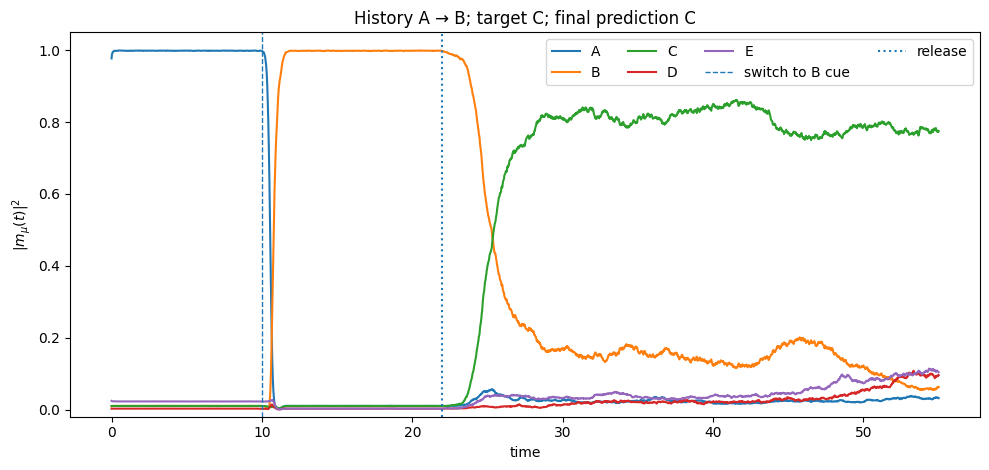

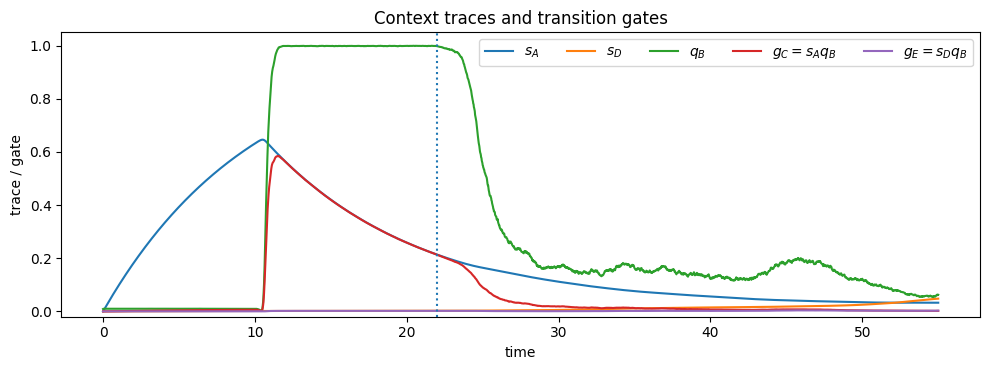

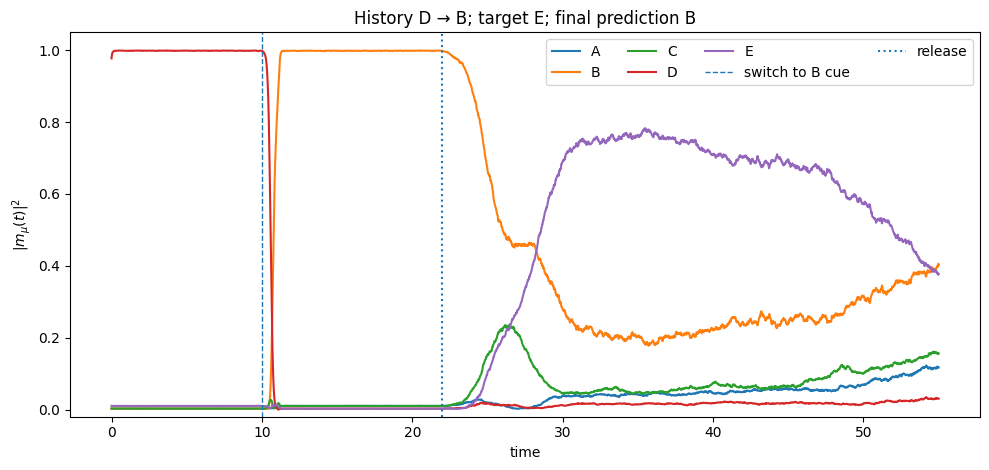

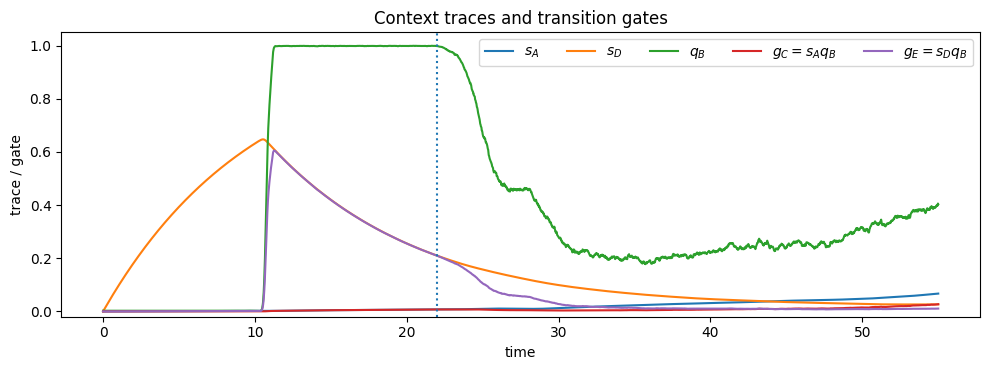

In [6]:

def plot_trial(result):
    t = result["times"]
    q = result["overlaps"]
    s = result["traces"]
    gates = result["gates"]
    p = result["parameters"]

    plt.figure(figsize=(10, 4.8))
    for mu, name in enumerate(MEMORY_NAMES):
        plt.plot(t, q[:, mu], label=name)

    plt.axvline(
        p["cue_1_end"],
        linestyle="--",
        linewidth=1,
        label="switch to B cue",
    )
    plt.axvline(
        p["cue_B_end"],
        linestyle=":",
        linewidth=1.5,
        label="release",
    )

    plt.xlabel("time")
    plt.ylabel(r"$|m_\mu(t)|^2$")
    plt.title(
        f'History {result["history"]} → B; '
        f'target {result["target"]}; '
        f'final prediction {result["predicted_memory"]}'
    )
    plt.ylim(-0.02, 1.05)
    plt.legend(ncol=4)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3.8))
    plt.plot(t, s[:, A], label=r"$s_A$")
    plt.plot(t, s[:, D], label=r"$s_D$")
    plt.plot(t, q[:, B], label=r"$q_B$")
    plt.plot(t, gates[:, 0], label=r"$g_C=s_Aq_B$")
    plt.plot(t, gates[:, 1], label=r"$g_E=s_Dq_B$")

    plt.axvline(p["cue_B_end"], linestyle=":", linewidth=1.5)
    plt.xlabel("time")
    plt.ylabel("trace / gate")
    plt.title("Context traces and transition gates")
    plt.ylim(-0.02, 1.05)
    plt.legend(ncol=5)
    plt.tight_layout()
    plt.show()


plot_trial(trial_AB)
plot_trial(trial_DB)



### Interpretation

A successful proof of concept has the following signatures:

1. During the first cue period, either \(q_A\) or \(q_D\) becomes large.
2. During the second cue period, \(q_B\) becomes large.
3. At release, the slow trace of the earlier state remains nonzero.
4. The corresponding context gate becomes dominant:
   \[
   g_C=s_Aq_B
   \quad\text{or}\quad
   g_E=s_Dq_B.
   \]
5. The final overlap is largest for \(C\) after \(A\to B\), and for \(E\) after \(D\to B\).

Because the memories and intrinsic frequencies are random, not every seed is expected to work with one fixed parameter set. The next section measures how often the intended branch is recovered.


## 3. Small robustness test over random seeds

In [7]:

def evaluate_seed(seed, params=None):
    outcomes = {}

    for history, target in [("A", "C"), ("D", "E")]:
        result = run_trial(
            history=history,
            seed=seed,
            params=params,
        )
        outcomes[history] = {
            "target": target,
            "prediction": result["predicted_memory"],
            "success": result["predicted_memory"] == target,
            "target_overlap": result["final_overlaps"][
                MEMORY_NAMES.index(target)
            ],
        }

    return outcomes


n_seeds = 20
all_outcomes = [evaluate_seed(seed) for seed in range(n_seeds)]

success_A = np.mean(
    [outcome["A"]["success"] for outcome in all_outcomes]
)
success_D = np.mean(
    [outcome["D"]["success"] for outcome in all_outcomes]
)
joint_success = np.mean(
    [
        outcome["A"]["success"] and outcome["D"]["success"]
        for outcome in all_outcomes
    ]
)

print(f"A -> B -> C success rate: {success_A:.1%}")
print(f"D -> B -> E success rate: {success_D:.1%}")
print(f"Both branches correct:     {joint_success:.1%}")


A -> B -> C success rate: 65.0%
D -> B -> E success rate: 75.0%
Both branches correct:     45.0%


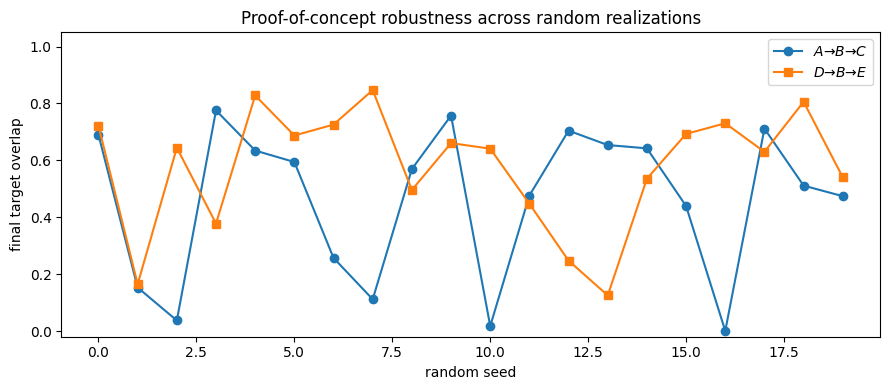

In [8]:

seeds = np.arange(n_seeds)
target_C = [
    outcome["A"]["target_overlap"]
    for outcome in all_outcomes
]
target_E = [
    outcome["D"]["target_overlap"]
    for outcome in all_outcomes
]

plt.figure(figsize=(9, 4))
plt.plot(seeds, target_C, "o-", label=r"$A\to B\to C$")
plt.plot(seeds, target_E, "s-", label=r"$D\to B\to E$")
plt.xlabel("random seed")
plt.ylabel("final target overlap")
plt.title("Proof-of-concept robustness across random realizations")
plt.ylim(-0.02, 1.05)
plt.legend()
plt.tight_layout()
plt.show()



## 4. Parameter scan

The most important competition is between:

- \(K_{\mathrm{mem}}\), which stabilizes the current attractor;
- \(K_{\mathrm{tr}}\), which pushes the state toward the context-selected target;
- \(\tau_s\), which controls how long the previous-state trace persists.

The following coarse scan reports the fraction of trials for which both branches are correct. It is intentionally small enough to run on a laptop.


In [ ]:

K_tr_values = [5.0, 7.0, 9.0, 11.0]
tau_values = [6.0, 10.0, 14.0]
scan_seeds = range(8)

score_matrix = np.zeros((len(tau_values), len(K_tr_values)))

for i, tau_s in enumerate(tau_values):
    for j, K_tr in enumerate(K_tr_values):
        successes = []

        for seed in scan_seeds:
            outcome = evaluate_seed(
                seed,
                params={
                    "K_tr": K_tr,
                    "tau_s": tau_s,
                },
            )
            successes.append(
                outcome["A"]["success"]
                and outcome["D"]["success"]
            )

        score_matrix[i, j] = np.mean(successes)

print("Rows: tau_s =", tau_values)
print("Columns: K_tr =", K_tr_values)
print(score_matrix)


In [ ]:

plt.figure(figsize=(7, 4.5))
image = plt.imshow(
    score_matrix,
    origin="lower",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)
plt.xticks(
    np.arange(len(K_tr_values)),
    K_tr_values,
)
plt.yticks(
    np.arange(len(tau_values)),
    tau_values,
)
plt.xlabel(r"$K_{\mathrm{tr}}$")
plt.ylabel(r"$\tau_s$")
plt.title("Fraction of seeds with both branches correct")
plt.colorbar(image, label="joint success rate")
plt.tight_layout()
plt.show()



## 5. What would count as a convincing result?

This notebook establishes only a computational proof of concept. A stronger result would require:

- success across many random memory sets and initial conditions;
- comparison against a first-order baseline with no history trace;
- elimination of external cueing after a learned autonomous sequence is established;
- systematic scaling with \(N\), the number of memories, and the number of branch points;
- a principled transition tensor rather than two manually specified gates;
- stability or mean-field analysis explaining the observed parameter regime.

A useful immediate baseline is obtained by disabling context dependence:

```python
baseline = run_trial(
    history="A",
    seed=3,
    params={"K_tr": 0.0},
)
```

The expected outcome is that the network remains near \(B\), returns to another static attractor, or chooses a branch without using the preceding state.
